# Блок 2. Задача 1: наивный Байес

Цель: выполнить бинарную классификацию опухолей на датасете `Breast Cancer Wisconsin`.

Используется модель `GaussianNB`.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")


## Загрузка и анализ данных


In [7]:
cancer = load_breast_cancer(as_frame=True)
df_cancer = cancer.frame.copy()
df_cancer["target_name"] = df_cancer["target"].map(dict(enumerate(cancer.target_names)))

display(df_cancer.head())
print("Размер датасета:", df_cancer.shape)
print("Распределение классов:")
print(df_cancer["target_name"].value_counts())


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


Размер датасета: (569, 32)
Распределение классов:
target_name
benign       357
malignant    212
Name: count, dtype: int64


## Подготовка данных


In [8]:
X = df_cancer.drop(columns=["target", "target_name"])
y = df_cancer["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Обучение модели


In [9]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train_scaled, y_train)


GaussianNB()

## Метрики


Accuracy: 0.93
ROC-AUC: 0.987
              precision    recall  f1-score   support

   malignant       0.90      0.90      0.90        42
      benign       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



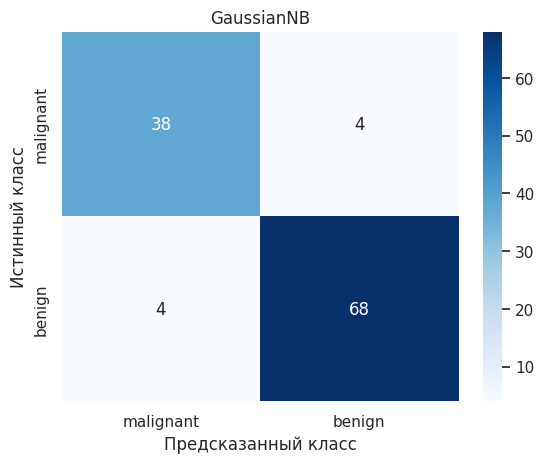

In [10]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=cancer.target_names,
    yticklabels=cancer.target_names,
)
plt.title("GaussianNB")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()


## Вывод

Входные данные соответствуют задаче бинарной классификации: используется датасет `Breast Cancer Wisconsin` размером `569 x 32`, в `X` входят `30` числовых признаков опухоли, а целевая переменная `y = target` содержит два класса: `malignant` и `benign`. Классы распределены неравномерно (`357` benign и `212` malignant), поэтому при разбиении используется `stratify=y`.

По текущему запуску `GaussianNB` получил `Accuracy = 0.930` и `ROC-AUC = 0.987`. Для класса `malignant` значения `precision`, `recall` и `f1-score` равны `0.90`, для класса `benign` - `0.94`. Это хороший базовый результат, но по `accuracy` и `f1-score` модель уступает KNN и SVM из следующих задач блока.

Наивный Байес подходит как быстрый вероятностный baseline: он показывает высокую способность ранжировать объекты по вероятности положительного класса (`ROC-AUC = 0.987`), но итоговые жёсткие предсказания дают больше ошибок, чем у более гибких моделей.
